# Example 21: k-Means Clustering

K-means clustering is an unsupervised machine learning technique used for grouping data points into clusters based on proximity. It works by iteratively ad randomly assigning data points to the nearest cluster centroid and then updating the centroids based on the mean of the data points in each cluster. This process continues until convergence, resulting in clusters that minimize the within-cluster variance. K-means clustering is often used for tasks such as customer segmentation, image compression, and data analysis.

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt

# Generate fake data
from sklearn.datasets import make_blobs

# For model and evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# Suppress KMeans warnings
from warnings import filterwarnings

The data generated is naturally clustered. We will attempt to construct those clusters and we will assume that we know the number of clusters to be 3. Note, however, that the number of assumed clusters is a hyperparameter that generally needs to be selected. 

Because k-means clustering is an unsupervised learning method, it generally does NOT have labels. However, there are cases when a dataset is partially labeled and this partial labeling gives rise to a testing set. Here, we will ignore y_train but we will use y_test to evaluate the resulting classification. 

One thing to note is that k-means clustering will cluster based on the number of clusters provided, but the labels assigned may be a permutation of the true labeling. For example, the clusters may be automatically labeled 0, 1, and 2, but in order to be compared to the testing set, cluster 0 should be labeled cluster 2 and cluster 2 should be labeled cluster 0 (or something similar). K-means clustering has no way of guessing the correct labeling for clusters because it is unsupervised. So if you have a labeled testing set, this should be a consideration. As we will see here, by coincidence, the labeling happens to be correct. 

In [2]:
# Generate synthetic data
X, y = make_blobs(n_samples=300, centers=3, random_state=21, cluster_std=0.75)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [3]:
clusters = 3

Constructing k-means clustering involves the sci-kit learn and follows its standard form for other models. 

In [4]:
# Suppress warnings
filterwarnings("ignore", category=FutureWarning, module="sklearn")

# Create a KMeans clustering model
kmeans = KMeans(n_clusters=clusters, random_state=22)
kmeans.fit(X_train)

# Predict cluster labels
labels = kmeans.labels_

# Classification of testing set
y_pred = kmeans.predict(X_test)

K-means clustering works by constructing a center of the cluster. It classifies points based on the closest cluster center. Below we code the classification of the training set as well as the entire space. 

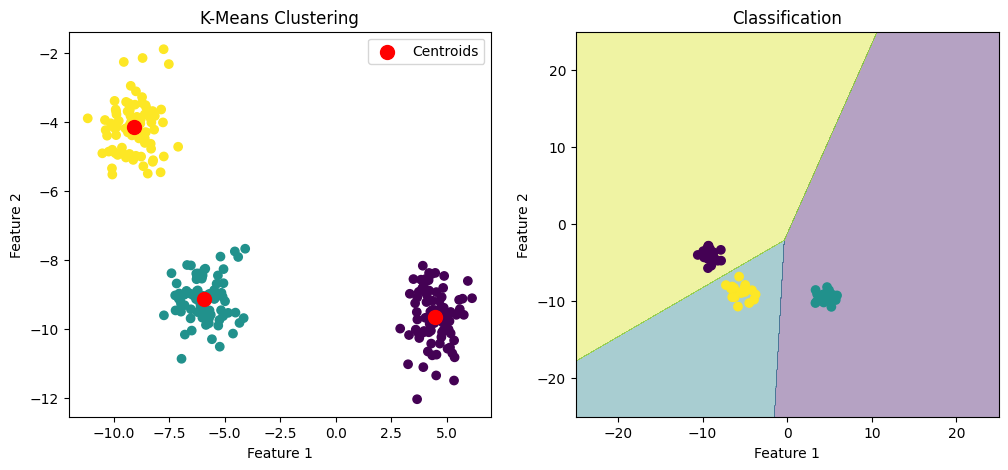

In [5]:
# Visualize the clusters

plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.scatter(X_train[:, 0], X_train[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='red', label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering')
plt.legend()

# Create a classification task based on cluster labels
xx, yy = np.meshgrid(np.arange(-25, 25, 0.01),
                     np.arange(-25, 25, 0.01))

# Plot the decision boundary
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Visualize the classification
plt.subplot(122)
plt.contourf(xx, yy, Z, alpha=0.40)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', label='Testing Set')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Classification')
plt.show()

Below are some methods of scoring. Because we are performing classification, we can use the classification report, which details accuracy, recall, and precision. In addition, we have the Silhouette score and the Adjusted Rand Index. 

### Silhouette Score

The Silhouette score is a measure of how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It quantifies the quality of clustering, where a higher Silhouette score indicates that the object is well-matched to its cluster and poorly matched to neighboring clusters. The Silhouette score for a single data point i is calculated as follows:

- Calculate the average distance between the data point $i$ and all other data points in the same cluster, denoted as $a(i)$.
- Calculate the average distance between the data point $i$ and all data points in the nearest cluster that $i$ is not a part of, denoted as $b(i)$.
- The Silhouette score for data point $i$ is given by: $$s(i) = \frac{b(i) - a(i)}{\max \{a(i), b(i)\}}$$

The overall Silhouette score for a clustering solution is the average of the Silhouette scores for all data points, and it ranges from -1 to 1. A high positive Silhouette score indicates good clustering, where objects within the same cluster are close to each other, and well separated from objects in other clusters.

### Adjusted Rand Index (ARI)

The Adjusted Rand Index is a measure of the similarity between two data clusterings, adjusted for chance. It quantifies the agreement between the true labels (ground truth) and the predicted labels obtained from a clustering algorithm. The ARI considers all pairs of data points and assesses whether they are in the same or different clusters in both the true and predicted clusterings.

The ARI is calculated as follows:

- Let a be the number of pairs of data points that are in the same cluster in both the true and predicted clusterings.
- Let b be the number of pairs of data points that are in different clusters in both the true and predicted clusterings.
- Let c be the number of pairs of data points that are in the same cluster in the true clustering but in different clusters in the predicted clustering.
- Let d be the number of pairs of data points that are in different clusters in the true clustering but in the same cluster in the predicted clustering.
  
The ARI is then calculated using the formula:

$$ARI = \frac{a + b}{a + b + c + d}$$

The ARI ranges from -1 to 1, where a higher value indicates a better agreement between the true and predicted clusterings. An ARI of 1 means that the two clusterings are identical, while a value close to 0 suggests that the clusterings are random with respect to each other.

In [6]:
# Evaluate clustering using silhouette score
silhouette_avg = silhouette_score(X_train, labels)
print(f'Silhouette Score: {silhouette_avg:.2f}')

# Evaluate clustering using adjusted Rand index
rand_index = adjusted_rand_score(y_test, y_pred)
print(f'Adjusted Rand Index: {rand_index:.2f}')

# Evaluate classification using the classification report
classification_rep = classification_report(y_test, y_pred)
print('Classification Report:\n', classification_rep)

Silhouette Score: 0.81
Adjusted Rand Index: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      22.0
           1       0.00      0.00      0.00      19.0
           2       0.00      0.00      0.00      19.0

    accuracy                           0.00      60.0
   macro avg       0.00      0.00      0.00      60.0
weighted avg       0.00      0.00      0.00      60.0

